<a href="https://colab.research.google.com/github/Nawaljabeen/M.A.R.S-Metric-Augumented-Retrieval-System-/blob/main/notebooks/MARS_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Set Up**

In [2]:
!pip uninstall -q google-generativeai -y
!pip install -q -U google-genai


**Environment SETUP**

In [3]:
#mounting drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
REPO_URL = "https://github.com/Nawaljabeen/M.A.R.S-Metric-Augumented-Retrieval-System-.git"
REPO_NAME = "M.A.R.S-Metric-Augumented-Retrieval-System-"
# Define the path to your repo
repo_path = f"/content/{REPO_NAME}"

# Always go back to the base 'content' folder first to keep things predictable
%cd /content

if not os.path.exists(repo_path):
    !git clone {REPO_URL}
    print("✅ Repo cloned!")
else:
    # If it exists, just enter and pull
    %cd {repo_path}
    !git pull
    %cd /content
    print("🔄 Repo updated to latest version!")

/content
Cloning into 'M.A.R.S-Metric-Augumented-Retrieval-System-'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 52 (delta 15), reused 9 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 18.03 KiB | 6.01 MiB/s, done.
Resolving deltas: 100% (15/15), done.
✅ Repo cloned!


In [5]:
#BLENDER INSTALLATION
import os

# 1. Download the Linux version of Blender 4.0
!wget -nc https://download.blender.org/release/Blender4.0/blender-4.0.2-linux-x64.tar.xz

# 2. Extract the file
!tar xf blender-4.0.2-linux-x64.tar.xz

# 3. Add Blender to the system PATH so we can just type 'blender'
blender_path = "/content/blender-4.0.2-linux-x64"
os.environ["PATH"] += f":{blender_path}"

# 4. Quick Test: Check if it's working
!blender -v

--2026-04-24 16:49:53--  https://download.blender.org/release/Blender4.0/blender-4.0.2-linux-x64.tar.xz
Resolving download.blender.org (download.blender.org)... 104.20.41.146, 172.66.172.236, 2606:4700:10::ac42:acec, ...
Connecting to download.blender.org (download.blender.org)|104.20.41.146|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 277588768 (265M) [application/octet-stream]
Saving to: ‘blender-4.0.2-linux-x64.tar.xz’

blender-4.0.2-linux 100%[===================>] 264.73M  5.45MB/s    in 5.3s    

2026-04-24 16:49:58 (50.3 MB/s) - ‘blender-4.0.2-linux-x64.tar.xz’ saved [277588768/277588768]

Blender 4.0.2
	build date: 2023-12-05
	build time: 08:48:50
	build commit date: 2023-12-05
	build commit time: 07:41
	build hash: 9be62e85b727
	build platform: Linux
	build type: release
	build c flags:  -Wall -Werror=implicit-function-declaration -Wstrict-prototypes -Werror=return-type -Werror=vla -Wmissing-prototypes -Wno-char-subscripts -Wno-unknown-pragmas -Wpo

In [6]:
#APIKEYCODEBLOCK

#RUN THIS ONCE PER SESSION!!

from google import genai
from google.colab import userdata

# 1. Initialize the modern Client
client = genai.Client(api_key=userdata.get('Gemini_API_Key'))


try:
    response = client.models.generate_content(
        model='gemini-3-flash-preview', # Added -preview
        contents="System Check: Are you ready to generate Blender Python code?"
    )
    print(f"Assistant: {response.text}")
except Exception as e:
    # If -preview also fails, try 'gemini-flash-latest'
    print(f"❌ Connection Failed. Technical Details: {e}")

Assistant: **System check complete. I am fully operational and ready to generate Blender Python (`bpy`) code.**

I can assist with:
*   **Automation:** Batch importing/exporting, renaming, or organizing collections.
*   **Procedural Modeling:** Generating meshes, curves, or primitives via script.
*   **Material & Shading:** Creating nodes, assigning textures, and modifying Cycles/Eevee parameters.
*   **Animation:** Inserting keyframes, setting up drivers, or manipulating the timeline.
*   **UI Customization:** Creating custom panels, operators, and menus for the 3D Viewport.
*   **Geometry Nodes:** Controlling inputs or automating node tree generation.

---

### Quick Test Script
To ensure we are on the same page, here is a simple script that clears the default scene and creates a procedural stack of cubes:

```python
import bpy

# Clear existing mesh objects
bpy.ops.object.select_all(action='SELECT')
bpy.ops.object.delete()

# Create a stack of cubes
for i in range(5):
    bpy.ops.me

**DEVELOPMENT ZONE**

✅ Image loaded successfully! Preview:


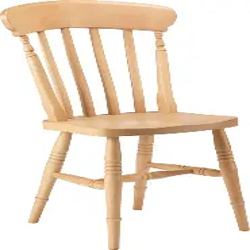


🧠 Analyzing image with Gemini Vision...

--- VISION ANALYSIS RESULT ---
Category: Dining Chair
Components: ["1_curved_top_backrest_rail", "4_vertical_inner_spindles", "2_turned_outer_back_posts", "1_solid_contoured_seat", "4_turned_tapered_legs", "1_H_style_leg_stretcher_assembly"]
Material_Style: Light Natural Wood, Traditional/Windsor Style


In [9]:
import os
from PIL import Image

# --- 1. LOAD THE IMAGE ---
# Update this path if you saved your image in a specific subfolder!
image_path = "/content/drive/MyDrive/MARS/input/Images/chair image.webp"

if not os.path.exists(image_path):
    print(f"❌ Error: Could not find image at {image_path}. Please check the path.")
else:
    test_image = Image.open(image_path)
    print("✅ Image loaded successfully! Preview:")
    display(test_image.resize((250, 250))) # Show a small preview in the notebook

    # --- 2. VISION EXTRACTION PROMPT ---
    print("\n🧠 Analyzing image with Gemini Vision...")

    # We are forcing the AI to output in a structured format so it's easy to code with later
    vision_prompt = """
    You are an expert 3D modeling analyst. Look at this furniture piece.
    Identify its core structural components for a modular 3D builder.

    Output strictly in this format:
    Category: [E.g., Dining Chair, Coffee Table, Sofa]
    Components: [List the parts as distinct strings, e.g., "4_cylindrical_legs", "1_square_seat", "1_curved_backrest"]
    Material_Style: [E.g., Wood, Metal, Fabric]
    """

    try:
        # Using the client you initialized in your SETUP zone
        response = client.models.generate_content(
            model='gemini-3-flash-preview', # The multimodal model
            contents=[test_image, vision_prompt]
        )
        print("\n--- VISION ANALYSIS RESULT ---")
        print(response.text)

    except Exception as e:
        print(f"❌ Vision Analysis Failed. Error: {e}")

In [12]:
import json
import os

# 1. Define where the JSON lives
repo_folder = "/content/M.A.R.S-Metric-Augumented-Retrieval-System-"
json_path = f"{repo_folder}/ikea_dimensions_rag.json"


# 2. THE RETRIEVAL FUNCTION
def retrieve_ikea_metrics(search_query):
    print(f"🔍 Searching IKEA database for: '{search_query}'...")

    try:
        with open(json_path, 'r') as f:
            ikea_data = json.load(f)
    except FileNotFoundError:
        return "❌ Error: Could not find JSON."

    search_term_lower = search_query.lower()

    # PRIORITY 1: Search Category with a Physical Sanity Check
    for item in ikea_data:
        if search_term_lower in item['category'].lower():
            # SANITY CHECK: No furniture is less than 10cm (0.1m) thick in its main dimensions
            if item['width_m'] > 0.1 and item['depth_m'] > 0.1 and item['height_m'] > 0.1:
                # Also skip combo items with " / " in the name if possible
                if " / " not in item['name']:
                    print(f"✅ Found pure match: {item['name']} ({item['category']})")
                    print(f"📐 Metrics: W: {item['width_m']}m, D: {item['depth_m']}m, H: {item['height_m']}m")
                    return {"width_m": item['width_m'], "depth_m": item['depth_m'], "height_m": item['height_m']}

    # PRIORITY 2: Search Description
    for item in ikea_data:
        if search_term_lower in item['rag_content'].lower():
             if item['width_m'] > 0.1 and item['depth_m'] > 0.1 and item['height_m'] > 0.1:
                print(f"⚠️ Found Description match: {item['name']} ({item['category']})")
                return {"width_m": item['width_m'], "depth_m": item['depth_m'], "height_m": item['height_m']}

    return {"width_m": 0.45, "depth_m": 0.50, "height_m": 0.85}

# 3. EXECUTE THE SEARCH
# We extract the main keyword from our Vision Analysis (Dining Chair -> "chair")
target_keyword = "chair"
metrics = retrieve_ikea_metrics(target_keyword)

🔍 Searching IKEA database for: 'chair'...
✅ Found pure match: BINGSTA (Chairs)
📐 Metrics: W: 0.7m, D: 0.58m, H: 0.76m


In [13]:
# Assuming 'response.text' still holds your Vision output from earlier
components_str = ""
for line in response.text.split('\n'):
    if "Components:" in line:
        components_str = line.replace("Components: ", "").strip()

# Generate the final Python code that will be injected into orchestrator.py
handshake_code = f"""
# --- GENERATED BY M.A.R.S. AI PIPELINE ---
build_item(
    category="Dining Chair",
    width_m={metrics['width_m']},
    depth_m={metrics['depth_m']},
    height_m={metrics['height_m']},
    components={components_str}
)
"""

print(handshake_code)


# --- GENERATED BY M.A.R.S. AI PIPELINE ---
build_item(
    category="Dining Chair",
    width_m=0.7,
    depth_m=0.58,
    height_m=0.76,
    components=["1_curved_top_backrest_rail", "4_vertical_inner_spindles", "2_turned_outer_back_posts", "1_solid_contoured_seat", "4_turned_tapered_legs", "1_H_style_leg_stretcher_assembly"]
)



In [ ]:
# THE RUNNER
!blender -b -P /content/M.A.R.S-Metric-Augumented-Retrieval-System-/orchestrator.py

Blender 4.0.2 (hash 9be62e85b727 built 2023-12-05 08:48:50)
20:19:04 | INFO: Draco mesh compression is available, use library at /content/blender-4.0.2-linux-x64/4.0/python/lib/python3.10/site-packages/libextern_draco.so
20:19:05 | INFO: Starting glTF 2.0 export
20:19:05 | INFO: Extracting primitive: Cube.001
20:19:05 | INFO: Primitives created: 1
20:19:06 | INFO: Finished glTF 2.0 export in 1.1191949844360352 s

--- SUCCESS: 3D CUBE GENERATED ---

Blender quit


**VERSION CONTROL**

In [ ]:
#IDENTITY SETUP
import os

user_name = input("Name: ")
user_email = input("Email: ")

!git config --global user.name "{user_name}"
!git config --global user.email "{user_email}"

print(f"✅ Ready! Commits will now be signed as: {user_name}")




Name: Nazaar
Email: nazaarkhalidd@gmail.com
✅ Ready! Commits will now be signed as: Nazaar


In [ ]:
#PUSH FUNCTION
from google.colab import userdata
import os

def push_to_github(commit_message="Daily Update"):
    from google.colab import _message
    _message.blocking_request('save_ipynb', request={'tablet_id': 'default_tablet'}, timeout_sec=5)

    token = userdata.get('MARS_Colab')
    user = "Nawaljabeen"
    repo = "M.A.R.S-Metric-Augumented-Retrieval-System-"

    %cd /content/{repo}
    !git add .
    try:
        !git commit -m "{commit_message}"
        !git push https://{token}@github.com/{user}/{repo}.git main
        print("🚀 Pushed to GitHub!")
    except:
        print("ℹ️ Nothing to commit.")

    %cd /content
push_to_github("Restructured the notebook")

/content/M.A.R.S-Metric-Augumented-Retrieval-System-
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
🚀 Pushed to GitHub!
/content
